In [4]:
import pandas as pd
data=pd.read_csv("insurance.csv")
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [8]:
import matplotlib.pyplot as plt

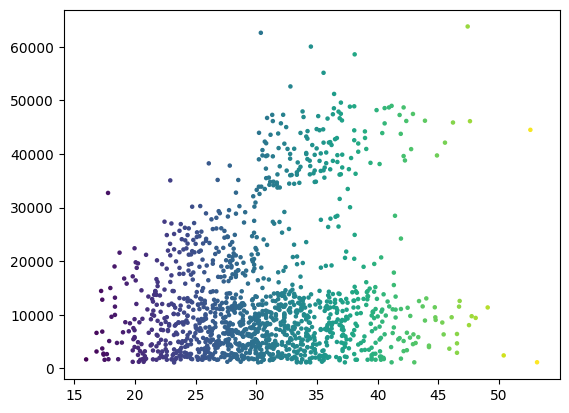

In [16]:
plt.scatter(x=data["bmi"],y=data["charges"] ,s=5, c=data["bmi"],
    cmap="viridis")

In [36]:
from sklearn.model_selection import train_test_split
x_data=data.drop(columns=["region","children","charges"])
y_data=data["charges"]

In [39]:
print(type(x_data))
x_data["sex"]=x_data["sex"].map({"female":1,"male":0})
x_data["smoker"]=x_data["smoker"].map({"yes":1,"no":0})



<class 'pandas.core.frame.DataFrame'>


In [40]:
x_train,x_test,y_train, y_test=train_test_split(x_data,y_data,test_size=0.2,random_state=42)

In [41]:
x_train

,age,sex,bmi,smoker
560,46,1,19.950,0
1285,47,1,24.320,0
1142,52,1,24.860,0
969,39,1,34.320,0
486,54,1,21.470,0
...,...,...,...,...
1095,18,1,31.350,0
1130,39,1,23.870,0
1294,58,0,25.175,0
860,37,1,47.600,1


In [44]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [52]:
print(y_pred)
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print(f"evaluation={r2}")

[ 8.17949231e+03  7.42637039e+03  3.73410905e+04  8.63434290e+03
  2.73205126e+04  1.11214302e+04  5.66444927e+02  1.72732477e+04
  1.19552058e+03  1.03739389e+04  2.77192389e+04  8.91887073e+03
  5.47011515e+03  3.77293924e+04  4.08943608e+04  3.68756527e+04
  1.49314318e+04  3.61122132e+04  9.37741277e+03  3.18934293e+04
  2.58440433e+03  1.00938351e+04  3.14977391e+03  6.98878786e+03
  1.04379132e+04  1.29641183e+04  1.53105718e+04  5.21570470e+03
  9.16349073e+03  2.80548770e+03  8.22898510e+03  1.34632514e+04
  5.11840601e+03  2.58266940e+03  4.83508596e+03  1.29646427e+04
  2.35347977e+03  9.20308496e+03  3.33288057e+04  3.28012393e+04
  2.55281755e+03  4.23812692e+03  1.45014284e+04  1.19136699e+04
  8.52798908e+03  1.25796026e+04  4.71362342e+03  2.70561063e+03
  3.48684833e+04  8.87095939e+03  1.64805342e+04  2.55413077e+03
  1.21854085e+04  1.49484085e+03  1.40635776e+04  1.17497678e+04
  4.39070915e+03  3.12397627e+04  1.41388718e+04  1.28907752e+04
  1.50115651e+04  1.01462

In [56]:
n=x_test.shape[0]
p=x_test.shape[1]
adjusted_r2=1-((1-r2)*(n-1))/(n-p-1)
print(r2)
print(adjusted_r2)

0.7776757765738431
0.7742944195635594


In [1]:
import pandas as pd
insurance_data=pd.read_csv("insurance.csv")

In [2]:
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [26]:
insurance_data=pd.get_dummies(insurance_data,columns=["region"],drop_first=False,dtype=int)

In [27]:
x_data=insurance_data.drop(columns=["charges"])
x_data["sex"]=x_data["sex"].map({"female":1,"male":0})
x_data["smoker"]=x_data["smoker"].map({"yes":1,"no":0})

In [28]:
y_data=insurance_data["charges"]
y_data

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_data,y_data,test_size=.20,random_state=42)

In [30]:
model=LinearRegression()
model.fit(x_train,y_train)
pred=model.predict(x_test)
pred

array([ 8969.55027444,  7068.74744287, 36858.41091155,  9454.67850053,
       26973.17345656, 10864.11316424,   170.28084137, 16903.45028662,
        1092.43093614, 11218.34318352, 28101.68455267,  9377.73460205,
        5263.0595179 , 38416.04221107, 40255.82339284, 37098.25353123,
       15240.39392306, 35912.88264434,  9112.52398703, 31461.92108909,
        3847.68845883, 10130.12001517,  2370.54189389,  7140.21550828,
       11301.76782638, 12961.65366224, 14509.47251876,  6159.8976107 ,
        9963.85857263,  2177.85718217,  9115.93673493, 13073.68932159,
        4561.82376202,  3408.20756033,  4459.81359745, 13032.06505076,
        1979.99357292,  8813.28303302, 33271.29124448, 32585.51583927,
        3908.76090964,  4326.10774721, 14142.81326533, 11423.45494846,
        8774.13955311, 12097.28051001,  5281.57353499,  3150.5596042 ,
       35494.46461214,  9150.1124786 , 15836.84575621,  2343.57470069,
       12364.78414194,  1482.29488266, 13389.06105161, 12573.57395972,
      

In [31]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,pred)
print(r2)

0.7835929767120723


In [32]:
n=x_test.shape[0]
p=x_test.shape[1]
adjusted_r2=1-((1-r2)*(n-1))/(n-p-1)
print(r2)
print(adjusted_r2)

0.7835929767120723
0.7760438945043538


In [34]:
#overfitting and underfitting check
y_train_pred=model.predict(x_train)
r2_train=r2_score(y_train,y_train_pred)
print(r2)
print(r2_train)


0.7835929767120723
0.7417255854683333
